# 1.0 Preprocessing and data visualisation

# Preprocessing

In [1]:
import re
import html
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import pandas as pd

The code in the cell below expands upon the code for preprocessing from *Zwerfverzen: De computationele detectie van intertekstualiteit in de Middelnederlandse epiek* by Mike Kestemont (2025):

In [2]:
LACUNA = re.compile(r'(?<!.ii)\.(\s*\.)+(?![A-Za-z])')
#one period followed by one or more periods (with optional spaces between periods). No alphabetic characters can immediately
#follow after the period to avoid matches with numbers followed after a period, such as in: 'Hoe die grave Gy in gevancnessen 
#voer ende sine ridders met. .vii. '. A match is also excluded if it is preceded by '.ii' to specifically prevent the following
#line from matching: 'Sine waren verslagen dan .c. ende .ii..'

def load_file(path):
    with open(path) as f:
        xml_text = f.read()
    
    
    xml_text = xml_text.replace('&oudpond;', '')
    xml_text = xml_text.replace('&supm;', 'm') #replace these superscript letters with lowercase letters
    xml_text = xml_text.replace('&supM;', 'm')
    xml_text = xml_text.replace('&supc;', 'c')
    xml_text = xml_text.replace('&supt;', 't')
    xml_text = xml_text.replace('&supn;', 'n')
    xml_text = xml_text.replace('&sups;', 's')
    xml_text = xml_text.replace('&supd;', 'd')
    xml_text = xml_text.replace('&uring;', 'u') #replace ů with u
    xml_text = xml_text.replace('&lt;', '') #remove < and >
    xml_text = xml_text.replace('&gt;', '')
    xml_text = html.unescape(xml_text) #convert HTML character entities not included in the code above to the Unicode equivalent

    soup = BeautifulSoup(xml_text, "xml")
    
    #extract and clean lines:
    lines = []
    first_div = soup.find('div')
    nr_lines = 0
    nr_subtitles = 0
    nr_titles = 0
    nr_lacuna = 0
    #Only extract from the second div node onward!
    #(For Heelu: excludes the 'Voorrede van den afschryver', For Velthem: excludes 'Die Prologhe'.)
    for line in soup.find_all(['l', 'head']):    #find all l and head nodes
        if line.name == 'head':
            #Include the chapter subtitles for Velthem
            if line.get('type') == 'subchapter':
                text = line.get_text().strip()
                if text and not re.search(LACUNA, text):
                    line = ''.join([char for char in text if char.isalpha() or char.isspace()]).strip()
                    line = line.replace('[', '') #Remove all instances of '['
                    line = line.replace(']', '') #Remove all instances of ']'
                    if line and line not in ('Varianten Spiegel Gentsche Fragmenten','Varianten Spiegel Leuvensch Fragment'):
                        lines.append(line)
                        nr_subtitles +=1
                        #print(line)
                else:
                    lines.append('[...]')
                    nr_lacuna += 1
                    #print(text)
                    
            #Include the chapter titles for Velthem
            elif line.get('type') == 'chapter' and line.get_text().strip() !='[DIE PROLOGHE.]':
                text = line.get_text().strip()
                if text and not re.search(LACUNA, text):
                    line = ''.join([char for char in text if char.isalpha() or char.isspace()]).strip()
                    line = line.replace('[', '') #Remove all instances of '['
                    line = line.replace(']', '') #Remove all instances of ']'
                    if line:
                        lines.append(line)
                        nr_titles += 1
                        #print(line)
                else:
                    lines.append('[...]')
                    nr_lacuna += 1
                    #print(text) #check which lines are being filtered out     
            continue
                
        if first_div in line.parents:   #skip the first div element
            continue
            
        text = line.get_text().strip()
        if text and not re.search(LACUNA, text):
            line = ''.join([char for char in text if char.isalpha() or char.isspace()]).strip()
            #Relevant for Velthem:
            line = line.replace('[', '') #Remove all instances of '['
            line = line.replace(']', '') #Remove all instances of ']'
            if line:
                lines.append(line)
                nr_lines+= 1
        else:
            lines.append('[...]')
            nr_lacuna += 1
            #print(text) #check which lines are being filtered out
    print("verse lines:", nr_lines, "/ chapter subtitles:", nr_subtitles, "/ titles:", nr_titles, "/ lacuna (replaced by [...]):", nr_lacuna, "/ total extracted lines:", len(lines))
            
    return lines

In [3]:
#Apply the load_file function to the XML files from Corpus Middelnederlands
print("Heelu:")
Heelu = load_file(r'data\Heelu\CorpusMNL_rijmkroniek_van_woeringen_Heelu.xml') 
print("Velthem:")
Velthem = load_file(r'data\Velthem\CorpusMNL_spiegel_historiael_5_Velthem.xml')

Heelu:
verse lines: 8947 / chapter subtitles: 0 / titles: 0 / lacuna (replaced by [...]): 2 / total extracted lines: 8949
Velthem:
verse lines: 27343 / chapter subtitles: 384 / titles: 7 / lacuna (replaced by [...]): 101 / total extracted lines: 27835


In [4]:
print("Beginning Heelu:", "\n", Heelu[:10])
print("Beginning Velthem", "\n", Velthem[:10])

Beginning Heelu: 
 ['Vrouwe Margriete van Inghelant', 'Die seker hevet van Brabant', 'Tshertoghen Jans sone Jan', 'Want si dietsche tale niet en can', 'Daer bi willic haer ene gichte', 'Sinden van dietschen gedichte', 'Daer si dietsch in leeren moghe', 'Van haren sweer den hertoghe', 'Sindic haer daer bi beschreven', 'Want en mach niet scoenres geven']
Beginning Velthem 
 ['Vanden lantgrave van Doringen hoene die paus ten coninc coes j', 'Na des keysers Vrederijcs doet', 'Die menigen brachten in pinen groet', 'So coes die paus Innocent', 'Maer niet met alder heren concent', 'Den lantgrave van Doringen', 'Maer dese en conste niet bedwingen', 'Sijn wedersaken so dat hi', 'Niet coninc en hiet ende hier bi', 'Sone willic op hem beginnen niet']


# Lemmatization (GaLAHaD)

Export the preprocessed text so the GaLAHad 'hug-tdn-1400-1600' model can be applied for lemmatization and POS-tagging:

In [5]:
def export_corpus_for_GaLAHaD(text):
    cnt = 0
    list_token = []
    list_line_count = []
    for line in text:
        cnt +=1
        for token in line.split():
            list_token.append(token)
            list_line_count.append(str(cnt))
    
    data = {'line': list_line_count,
            'token': list_token,
            'lemma':'',
             'pos':''}
    
    df = pd.DataFrame(data)
    return df

In [6]:
df_Heelu = export_corpus_for_GaLAHaD(Heelu)
print(df_Heelu)

df_Velthem = export_corpus_for_GaLAHaD(Velthem)
print(df_Velthem)

       line      token lemma pos
0         1     Vrouwe          
1         1  Margriete          
2         1        van          
3         1  Inghelant          
4         2        Die          
...     ...        ...   ...  ..
47377  8948     Vanden          
47378  8948      daghe          
47379  8948     bliven          
47380  8948   altemale          
47381  8949       AMEN          

[47382 rows x 4 columns]
         line      token lemma pos
0           1     Vanden          
1           1  lantgrave          
2           1        van          
3           1   Doringen          
4           1      hoene          
...       ...        ...   ...  ..
154953  27834         so          
154954  27834       waer          
154955  27834         ic          
154956  27834         si          
154957  27835       Amen          

[154958 rows x 4 columns]


In [7]:
#Save as tsv file
df_Heelu.to_csv('data\Heelu\Corpus_for_GaLAHaD_Heelu.tsv', sep="\t")
df_Velthem.to_csv('data\Velthem\Corpus_for_GaLAHaD_Velthem.tsv', sep="\t")

Load the tsv files from GaLAHaD:

In [8]:
Gal_Heelu = pd.read_csv('data\GaLAHaD\GaLAHaD_lemmatized_Heelu.tsv', sep = '\t')
Gal_Velthem = pd.read_csv('data\GaLAHaD\GaLAHaD_lemmatized_Velthem.tsv', sep = '\t')

In [9]:
Gal_Heelu = Gal_Heelu.drop('Unnamed: 0', axis=1)
Gal_Velthem = Gal_Velthem.drop('Unnamed: 0', axis=1)

Gal_Velthem.head()

,line,token,lemma,pos
0,1,Vanden,van+de,"ADP(type=pre)+PD(type=d-p,subtype=art,position..."
1,1,lantgrave,landgraaf,NOU-C(number=sg)
2,1,van,van,ADP(type=pre)
3,1,Doringen,Thüringen,NOU-P
4,1,hoene,hoen,NOU-C(number=sg)


Resolve empty values to avoid issues during data visualisations and the further analyses:

In [10]:
#The Slag bij Woeringen has one empty lemma entry
print(Gal_Heelu[Gal_Heelu['lemma'].isna()].index)
print(Gal_Heelu.iloc[34504])

#No empty values in the pos column
print(Gal_Heelu[Gal_Heelu['pos'].isna()].index)

#Replace empty entries in the 'lemma' column with an empty string. These were caused by verses replaced by [...]
Gal_Heelu['lemma'] = Gal_Heelu['lemma'].fillna('')
print(Gal_Heelu.iloc[34504])
print(Gal_Heelu.iloc[46602])

Index([34504, 46602], dtype='int64')
line      6498
token    [...]
lemma      NaN
pos         PC
Name: 34504, dtype: object
Index([], dtype='int64')
line      6498
token    [...]
lemma         
pos         PC
Name: 34504, dtype: object
line      8795
token    [...]
lemma         
pos         PC
Name: 46602, dtype: object


In [11]:
print(Gal_Heelu[Gal_Heelu['lemma'].isna()].index)
print(Gal_Heelu[Gal_Heelu['pos'].isna()].index) 
#no more empty lemma or pos entries!

Index([], dtype='int64')
Index([], dtype='int64')


In [12]:
#Lemma and pos entries that are empty for the Vijfde Partie
print(Gal_Velthem[Gal_Velthem['lemma'].isna()].index)
print(Gal_Velthem[Gal_Velthem['pos'].isna()].index)

Index([    10,   3253,   4401,   5150,   5151,   5152,   5153,   5154,   5155,
         5156,
       ...
       151816, 151817, 151818, 151819, 152085, 152086, 152087, 152088, 153125,
       153333],
      dtype='int64', length=109)
Index([68066], dtype='int64')


In [13]:
#Check the content of each empty lemma instance
for idx, entry in Gal_Velthem['lemma'].items(): 
    if isinstance(entry, str): 
        continue 
    else: 
        print(Gal_Velthem.loc[idx])

#Once again, these were caused by [...]        
#However, a few Nan values also appear in the lemma column for the numerals 'i' (line 1457, line 10280, line 14384,line 17497) 
# or 'j' (line 1, line 4366, line 12103, line 21003). These tokens will be added to the lemma column to insure accurate word counts 
#during data visualisation

Gal_Velthem.loc[Gal_Velthem['lemma'].isna(), 'lemma'] = np.where(
    Gal_Velthem.loc[Gal_Velthem['lemma'].isna(), 'token'] == '[...]', #when [...] is present under 'token', lemma becomes ''
    "",
    Gal_Velthem.loc[Gal_Velthem['lemma'].isna(), 'token'])
    

line       1
token      j
lemma    NaN
pos       PC
Name: 10, dtype: object
line       579
token    [...]
lemma      NaN
pos         PC
Name: 3253, dtype: object
line       785
token    [...]
lemma      NaN
pos         PC
Name: 4401, dtype: object
line       926
token    [...]
lemma      NaN
pos         PC
Name: 5150, dtype: object
line       927
token    [...]
lemma      NaN
pos         PC
Name: 5151, dtype: object
line       928
token    [...]
lemma      NaN
pos         PC
Name: 5152, dtype: object
line       929
token    [...]
lemma      NaN
pos         PC
Name: 5153, dtype: object
line       930
token    [...]
lemma      NaN
pos         PC
Name: 5154, dtype: object
line       931
token    [...]
lemma      NaN
pos         PC
Name: 5155, dtype: object
line       932
token    [...]
lemma      NaN
pos         PC
Name: 5156, dtype: object
line       933
token    [...]
lemma      NaN
pos         PC
Name: 5157, dtype: object
line       934
token    [...]
lemma      NaN
pos         PC
Name

line     27548
token    [...]
lemma      NaN
pos         PC
Name: 153333, dtype: object


In [14]:
#Closer inspection of the NaN values in the pos column
print(Gal_Velthem.iloc[68066]) #incorrect lemmatisation of inde (in + de)

line     12099
token     inde
lemma       en
pos        NaN
Name: 68066, dtype: object


In [15]:
#Fix instances of NaN in pos column
Gal_Velthem.loc[68066, "pos"] = "ADP(type=pre)+PD(type=d-p,subtype=art,position=prenom)"
Gal_Velthem.loc[68066, "lemma"] = "in+de"

print(Gal_Velthem.iloc[68066])

line                                                 12099
token                                                 inde
lemma                                                in+de
pos      ADP(type=pre)+PD(type=d-p,subtype=art,position...
Name: 68066, dtype: object


In [16]:
print(Gal_Velthem[Gal_Velthem['lemma'].isna()].index)
print(Gal_Velthem[Gal_Velthem['pos'].isna()].index) 
#no more empty lemma or pos entries!

Index([], dtype='int64')
Index([], dtype='int64')


Recombine the lemmatized tokens into verse lines and create a dataframe for the corpus:

In [17]:
#combine the lemmatized tokens into verse lines
lemma_lines_Heelu = Gal_Heelu.groupby('line')['lemma'].apply(lambda x: " ".join(x)).tolist()
lemma_lines_Velthem = Gal_Velthem.groupby('line')['lemma'].apply(lambda x: " ".join(x)).tolist()
    
lemma_lines_Heelu[:10]

['vrouwe Margriet van Engeland',
 'die zeker hebben van Brabant',
 'de+hertog Jans zoon Jan',
 'want zij Diets taal niet ne kunnen',
 'daar bij willen+ik zij een gift',
 'zinnen van Diets gedicht',
 'daar zij Diets in leren mogen',
 'van haar zweer de hertog',
 'zijn+ik zij daar bij beschrijven',
 'want ne mogen niet schoeneres geven']

In [18]:
df_corpus = [{'author': 'Heelu','title': 'rijmkroniek van woeringen', 'lines': Heelu, 'lines_lemmatized': lemma_lines_Heelu},
             {'author': 'Velthem','title': 'vijfde partie', 'lines': Velthem, 'lines_lemmatized': lemma_lines_Velthem}]

Create and save XML files with the added data from GaLAHaD:

In [19]:
from tqdm import tqdm 
import lxml.etree
from lxml import etree
from typing import List

for text in tqdm(df_corpus):
    folder = text['author']
    title = text['title']
    root = lxml.etree.Element('text')
    root.attrib['id'] = title
    
    lines: List[str] = [l for l in text['lines']]
    for nb, line in enumerate(lines):
        l_node = lxml.etree.Element('l')
        l_node.attrib['n'] = str(nb + 1)  #nb starts at 0, so add 1
        if line == '[...]':
            l_node.attrib['status'] = 'lacuna' #These should not be removed to retain accurate verse counts
        else:
            if folder == 'Heelu':
                #only extract the GaLAHaD info for the current line + convert the dataframe segment into a list of dictionaries
                for w in Gal_Heelu[Gal_Heelu['line'] == nb + 1].to_dict('records'):
                    w_node = lxml.etree.Element('w')
                    for tag in ('token', 'lemma', 'pos'):
                        subnode = lxml.etree.Element(tag)
                        subnode.text = w[tag]
                        w_node.append(subnode)
                    
                    l_node.append(w_node)
                
                l_node.attrib['tokens'] = text['lines'][nb]
                l_node.attrib['lemmas'] = text['lines_lemmatized'][nb]
                    
            elif folder == 'Velthem': 
                for w in Gal_Velthem[Gal_Velthem['line'] == nb + 1].to_dict('records'):
                    w_node = lxml.etree.Element('w')
                    for tag in ('token', 'lemma', 'pos'):
                        subnode = lxml.etree.Element(tag)
                        subnode.text = w[tag]
                        w_node.append(subnode)

                    l_node.append(w_node)
                
                l_node.attrib['tokens'] = text['lines'][nb]
                l_node.attrib['lemmas'] = text['lines_lemmatized'][nb]
                
            else:
                print('ERROR')
        
        root.append(l_node)
    
    #with open(f'data/Lemmatized_XML/lemmas_{title}.xml', 'w') as f:
        #f.write(lxml.etree.tostring(root, xml_declaration=True,
                                #pretty_print=True, encoding='utf-8').decode())
        
    with open(f'data/Lemmatized_XML/lemmas_{title}.xml', 'wb') as f:
        f.write(lxml.etree.tostring(root,xml_declaration=True,
                                pretty_print=True,encoding='utf-8'))
                                

100%|██████████| 2/2 [01:31<00:00, 45.92s/it]


# Data Visualization

Isolate all three parts of Velthems adaptation fromt the rest of the Vijfde Partie, as well as the segments from the *Slag bij Woeringen* that they are based on:

In [20]:
#These segments are based on Mantingh (2009), Besamusca (2009) and footnotes in Vander Linden et al. (1836)

#Heelu:
#Part 1
start = 'Coene ende hovesch melde ende wert' #vs. 117
end = 'Ende telle van den anderen yeesten voort' #vs. 1354

idx_start = next(i for i, line in enumerate(Heelu) if start in line) #index of the start string
idx_end = next(i for i, line in enumerate(Heelu) if end in line) # idx end string

Heelu_deel1 = Heelu[idx_start:idx_end+1]

#Part 2:
start = 'Van Gelre die gravinne' #vs. 1452
end = 'Alse nu die yeeste doet verstaen' # vs. 3920

idx_start = next(i for i, line in enumerate(Heelu) if start in line) #idx start string
idx_end = next(i for i, line in enumerate(Heelu) if end in line) # idx end string

Heelu_deel2 = Heelu[idx_start:idx_end+1]

#Part 3:
start = 'Het viel op enen sinxen dach' #vs. 3961
end = 'Vanden daghe bliven altemale' #vs. 8948

idx_start = next(i for i, line in enumerate(Heelu) if start in line) #idx start string
idx_end = next(i for i, line in enumerate(Heelu) if end in line) # idx end string

Heelu_deel3 = Heelu[idx_start:idx_end+1]

#Velthem:
#Part 1:
start = 'Coene hovesch milde ende weert' # vs. 2824, chapter 40, book I
end = 'Mar hier gaen vore ander dinge' #vs. 3543, chapter 46, book I (The last line of chapter 46)

idx_start = next(i for i, line in enumerate(Velthem) if start in line) #index of the start string
idx_end = next(i for i, line in enumerate(Velthem) if end in line) # idx end string

Velthem_deel1 = Velthem[idx_start:idx_end+1]

#Part 2:
start = 'God hi wilde dies gehingen' #vs. 3220, chapter 44, book II
end = 'Ward met enen stride gehint' #vs. 3976, chapter 54, book II (The last line of chapter 54)

idx_start = next(i for i, line in enumerate(Velthem) if start in line) #idx start string
idx_end = next(i for i, line in enumerate(Velthem) if end in line) # idx end string

Velthem_deel2 = Velthem[idx_start:idx_end+1]

#Part 3 (book III, kap. 2-21, 1318 verses):
start = 'Vanden parlemente dat om Limborch was hoet weder began ij' #Subtitle for chapter 2 of book III (right before vs. 71)
end = 'Die i jaer paus hadde gewesen' #vs. 1388, book III

idx_start = next(i for i, line in enumerate(Velthem) if start in line) #idx start string
idx_end = next(i for i, line in enumerate(Velthem) if end in line) # idx end string

Velthem_deel3 = Velthem[idx_start:idx_end+1]

In [21]:
#Total amount of verses
print('Heelu deel 1:', len(Heelu_deel1), ', Velthem deel 1:', len(Velthem_deel1))
print('Heelu deel 2:', len(Heelu_deel2), ', Velthem deel 2:', len(Velthem_deel2))
print('Heelu deel 3:', len(Heelu_deel3), ', Velthem deel 3:', len(Velthem_deel3))

Heelu deel 1: 1238 , Velthem deel 1: 727
Heelu deel 2: 2469 , Velthem deel 2: 767
Heelu deel 3: 4988 , Velthem deel 3: 1338


In [22]:
#Add the isolated Woeringen adaptation to the dataframe
df_corpus = pd.DataFrame(df_corpus)

Combined_adaptation = Velthem_deel1 + Velthem_deel2 + Velthem_deel3
df_corpus.loc[len(df_corpus)] = ["Velthem", "woeringen-adaptatie", Combined_adaptation, []]
df_corpus.head()

,author,title,lines,lines_lemmatized
0,Heelu,rijmkroniek van woeringen,"[Vrouwe Margriete van Inghelant, Die seker hev...","[vrouwe Margriet van Engeland, die zeker hebbe..."
1,Velthem,vijfde partie,[Vanden lantgrave van Doringen hoene die paus ...,[van+de landgraaf van Thüringen hoen die paus ...
2,Velthem,woeringen-adaptatie,"[Coene hovesch milde ende weert, In allen land...",[]


In [23]:
print('Length of the Woeringen-adaptation: ', len(Combined_adaptation))

Length of the Woeringen-adaptation:  2832


Comparison of the average amount of letters per verse line:

In [24]:
def avg_letters(lijst_verzen):
    letters_per_vers = [] #lists amount of letters per vers
    nr_of_lacuna = 0

    for vers in lijst_verzen:
        if vers == "[...]": #Exclude lines that were replaced during lacuna filtering
            nr_of_lacuna += 1
            continue
        else:
            letters_per_vers.append(len(vers))
    
    #calculate average amount of letters per verse
    total = sum(letters_per_vers)
    avg_letters = total/(len(lijst_verzen) - nr_of_lacuna)
    
    return letters_per_vers, avg_letters

In [25]:
avg_letters(Heelu_deel1[0:10]) #test

([34, 34, 25, 28, 36, 25, 26, 26, 27, 28], 28.9)

In [26]:
sums_l_H1, avg_l_H1 = avg_letters(Heelu_deel1)
sums_l_H2, avg_l_H2 = avg_letters(Heelu_deel2)
sums_l_H3, avg_l_H3 = avg_letters(Heelu_deel3)
sums_l_V1, avg_l_V1 = avg_letters(Velthem_deel1)
sums_l_V2, avg_l_V2 = avg_letters(Velthem_deel2)
sums_l_V3, avg_l_V3 = avg_letters(Velthem_deel3)
sums_l_H, avg_l_H = avg_letters(Heelu)
sums_l_V, avg_l_V = avg_letters(Velthem)

means_l_deel1 = [avg_l_H1, avg_l_V1]  #average amount of letters per verse, part 1 Heelu vs. Velthem
means_l_deel2 = [avg_l_H2, avg_l_V2]
means_l_deel3 = [avg_l_H3, avg_l_V3]
means_l_volledig = [avg_l_H, avg_l_V]

data = np.array([means_l_deel1, means_l_deel2, means_l_deel3, means_l_volledig])
data

array([[28.32875606, 29.19034483],
       [27.8853787 , 29.92167102],
       [28.97853991, 29.82696629],
       [28.58354756, 29.56793106]])

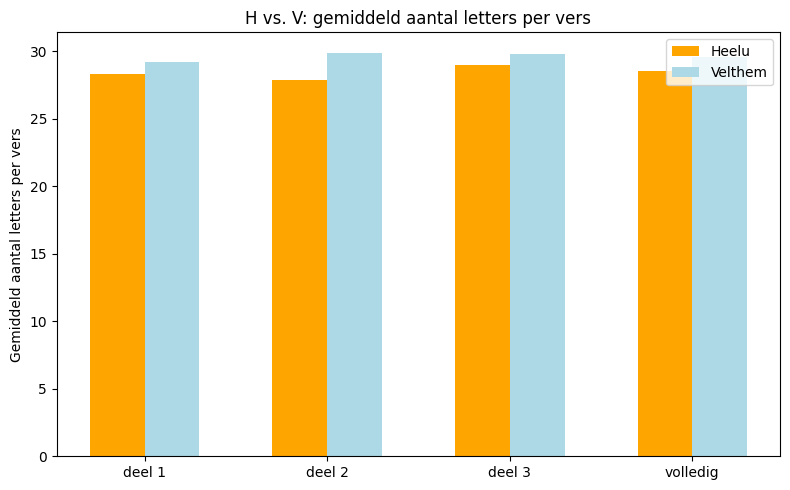

In [27]:
#x-axis: verses, y-axis: average amount of letters
x = np.arange(4)  # deel 1, deel 2, deel 3, entire Vijfde Partie

fig, ax = plt.subplots(figsize=(8,5))
width = 0.30

bars_H = ax.bar(x - width/2, data[:,0], width, label='Heelu', color='orange')
bars_V = ax.bar(x + width/2, data[:,1], width, label='Velthem', color='lightblue')

# Axis labels and ticks
ax.set_xticks(x)
ax.set_xticklabels(['deel 1', 'deel 2', 'deel 3', 'volledig'])
ax.set_ylabel('Gemiddeld aantal letters per vers')
ax.set_title('H vs. V: gemiddeld aantal letters per vers')
ax.legend()

plt.tight_layout()
plt.show()

Isolate the original and adapted text again, but this time using the lemmatized text:

In [28]:
#Replace the '+' between lemmatizations of clitics with a space
def remove_plus(text):
    result = []
    for line in (text):
        if '+' in line:
            line =  line.replace('+', ' ')
        result.append(line)
    return result

lemma_lines_Heelu_noplus = remove_plus(lemma_lines_Heelu)
lemma_lines_Velthem_noplus = remove_plus(lemma_lines_Velthem)
#lemma_lines_Heelu_noplus

In [29]:
#These segments are based on Mantingh (2009), Besamusca (2009) and footnotes in Willems (1836)

#Heelu:
#Part 1
start = 'koen en hoofs melde en worden' #vs. 117
end = 'en tellen van de ander geeste voortkomen' #vs. 1354

idx_start = next(i for i, line in enumerate(lemma_lines_Heelu_noplus) if start in line) #index of the start string
idx_end = next(i for i, line in enumerate(lemma_lines_Heelu_noplus) if end in line) # idx end string

Heelu_deel1_lem = lemma_lines_Heelu_noplus[idx_start:idx_end+1]

#Part 2:
start = 'van Gelre die gravin' #vs. 1452
end = 'als nu die jeest doen verstaan' # vs. 3920

idx_start = next(i for i, line in enumerate(lemma_lines_Heelu_noplus) if start in line) #idx start string
idx_end = next(i for i, line in enumerate(lemma_lines_Heelu_noplus) if end in line) # idx end string

Heelu_deel2_lem = lemma_lines_Heelu_noplus[idx_start:idx_end+1]

#Part 3:
start = 'het vallen op een zing dag' #vs. 3961
end = 'van de dag blijven altemaal' #vs. 8948

idx_start = next(i for i, line in enumerate(lemma_lines_Heelu_noplus) if start in line) #idx start string
idx_end = next(i for i, line in enumerate(lemma_lines_Heelu_noplus) if end in line) # idx end string

Heelu_deel3_lem = lemma_lines_Heelu_noplus[idx_start:idx_end+1]

#Velthem:
#Part 1:
start = 'koen hoofs mild en waard' # vs. 2824, chapter 40, book I
end = 'maar hier gaan voor ander ding' #vs. 3543, chapter 46, book I (The last line of chapter 46)

idx_start = next(i for i, line in enumerate(lemma_lines_Velthem_noplus) if start in line) #index of the start string
idx_end = next(i for i, line in enumerate(lemma_lines_Velthem_noplus) if end in line) # idx end string

Velthem_deel1_lem = lemma_lines_Velthem_noplus[idx_start:idx_end+1]

#Part 2:
start = 'God hij willen dies gehengen' #vs. 3220, chapter 44, book II
end = 'worden met een strijd hinten' #vs. 3976, chapter 54, book II (The last line of chapter 54)

idx_start = next(i for i, line in enumerate(lemma_lines_Velthem_noplus) if start in line) #idx start string
idx_end = next(i for i, line in enumerate(lemma_lines_Velthem_noplus) if end in line) # idx end string

Velthem_deel2_lem = lemma_lines_Velthem_noplus[idx_start:idx_end+1]

#Part 3 (book III, kap. 2-21, 1318 verses):
start = 'van de parlement dat om Limburg zijn hoe het weder beginnen -' #Subtitle for chapter 2 of book III (right before vs. 71)
end = 'die een jaar paus hebben wijzen' #vs. 1388, book III

idx_start = next(i for i, line in enumerate(lemma_lines_Velthem_noplus) if start in line) #idx start string
idx_end = next(i for i, line in enumerate(lemma_lines_Velthem_noplus) if end in line) # idx end string

Velthem_deel3_lem = lemma_lines_Velthem_noplus[idx_start:idx_end+1]

In [30]:
#sanity check
print('Heelu deel 1:', len(Heelu_deel1_lem), ', Velthem deel 1:', len(Velthem_deel1_lem))
print('Heelu deel 2:', len(Heelu_deel2_lem), ', Velthem deel 2:', len(Velthem_deel2_lem))
print('Heelu deel 3:', len(Heelu_deel3_lem), ', Velthem deel 3:', len(Velthem_deel3_lem))

Heelu deel 1: 1238 , Velthem deel 1: 727
Heelu deel 2: 2469 , Velthem deel 2: 767
Heelu deel 3: 4988 , Velthem deel 3: 1338


Comparison of the amount of words per verse, using the lemmatized verse lines:

In [31]:
def avg_woorden(lijst_verzen):
    woorden_per_vers = [] #lists amount of words per verse
    nr_of_lacuna = 0

    for vers in lijst_verzen:
        if vers == "[...]": #Exclude lines that were replaced during lacuna filtering
            nr_of_lacuna += 1
            continue
        else:
            woorden_per_vers.append(len(vers.split()))
    
    #calculate average amount of words per verse
    total = sum(woorden_per_vers)
    avg_woorden = total/(len(lijst_verzen) - nr_of_lacuna)
    
    return woorden_per_vers, avg_woorden

In [32]:
avg_woorden(Heelu_deel1_lem[:10]) #test

([6, 6, 4, 5, 7, 5, 5, 6, 6, 5], 5.5)

In [33]:
sums_w_H1, avg_w_H1 = avg_woorden(Heelu_deel1_lem)
sums_w_H2, avg_w_H2 = avg_woorden(Heelu_deel2_lem)
sums_w_H3, avg_w_H3 = avg_woorden(Heelu_deel3_lem)
sums_w_V1, avg_w_V1 = avg_woorden(Velthem_deel1_lem)
sums_w_V2, avg_w_V2 = avg_woorden(Velthem_deel2_lem)
sums_w_V3, avg_w_V3 = avg_woorden(Velthem_deel3_lem)
sums_w_H, avg_w_H = avg_woorden(lemma_lines_Heelu_noplus)
sums_w_V, avg_w_V = avg_woorden(lemma_lines_Velthem_noplus)


means_deel1 = [avg_w_H1, avg_w_V1]
means_deel2 = [avg_w_H2, avg_w_V2]
means_deel3 = [avg_w_H3, avg_w_V3]
means_volledig = [avg_w_H, avg_w_V]

data = np.array([means_deel1, means_deel2, means_deel3, means_volledig])
data

array([[5.37318255, 5.68638239],
       [5.36208991, 5.88657106],
       [5.53227747, 5.87369208],
       [5.46362722, 5.86552901]])

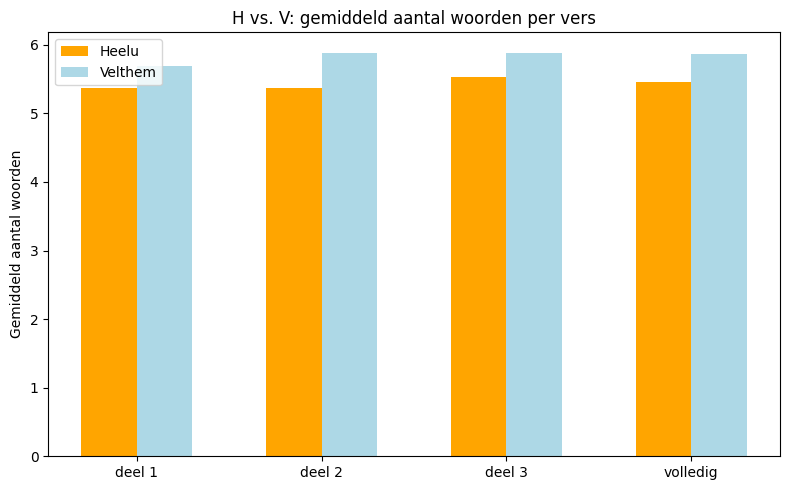

In [34]:
#Grafiek x-as: verzen, y-as: average amount of words 
x = np.arange(4)  # deel 1, deel 2, deel 3, volledig

fig, ax = plt.subplots(figsize=(8,5))
width = 0.30

bars_H = ax.bar(x - width/2, data[:,0], width, label='Heelu', color='orange')
bars_V = ax.bar(x + width/2, data[:,1], width, label='Velthem', color='lightblue')

# Axis labels and ticks
ax.set_xticks(x)
ax.set_xticklabels(['deel 1', 'deel 2', 'deel 3', 'volledig'])
ax.set_ylabel('Gemiddeld aantal woorden')
ax.set_title('H vs. V: gemiddeld aantal woorden per vers')
ax.legend()

plt.tight_layout()
plt.show()

In [35]:
#How many lines are directly copied. Lemmatized lines are used to disregard spelling differences.
cnt_exact = 0
lines_exact = []
for verse in lemma_lines_Velthem_noplus:
    if verse in lemma_lines_Heelu_noplus and verse != '': #Remove the lines that were replaced with '[...]' which have no lemma
        cnt_exact += 1
        lines_exact.append(verse)
    else:
        continue
        
print('amount of directly copied lines by Velthem:', cnt_exact)
#print('\n', lines_exact) #print this to see the specific lines

amount of directly copied lines by Velthem: 262


## Saving the dataframe

Add the Fifth Part, excluding the Woeringen adaptation, to the dataframe:

In [37]:
#These segments are based on Mantingh (2009), Besamusca (2009) and footnotes in Vander Linden et al. (1836)

#Velthem:
#Part 1:
start = 'Vanden lantgrave van Doringen hoene die paus ten coninc coes j' #chapter title 1
end = 'Coene hovesch milde ende weert' # vs. 2824, chapter 40, book I

idx_start = next(i for i, line in enumerate(Velthem) if start in line) #index of the start string
idx_end = next(i for i, line in enumerate(Velthem) if end in line) # idx end string

Velthem_deel1 = Velthem[idx_start:idx_end+1]

#Part 2:
start = 'Mar hier gaen vore ander dinge' #vs. 3543, chapter 46, book I (The last line of chapter 46)
end = 'God hi wilde dies gehingen' #vs. 3220, chapter 44, book II

idx_start = next(i for i, line in enumerate(Velthem) if start in line) #idx start string
idx_end = next(i for i, line in enumerate(Velthem) if end in line) # idx end string

Velthem_deel2 = Velthem[idx_start:idx_end+1]

#Part 3:
start = 'Ward met enen stride gehint' #vs. 3976, chapter 54, book II (The last line of chapter 54)
end = 'Vanden parlemente dat om Limborch was hoet weder began ij' #Subtitle for chapter 2 of book III (right before vs. 71)

idx_start = next(i for i, line in enumerate(Velthem) if start in line) #idx start string
idx_end = next(i for i, line in enumerate(Velthem) if end in line) # idx end string

Velthem_deel3 = Velthem[idx_start:idx_end+1]

#Part 4
start = 'Die i jaer paus hadde gewesen' #vs. 1388, book III
end = 'Ende mi mede so waer ic si' #second to last verse (excluding "Amen")

idx_start = next(i for i, line in enumerate(Velthem) if start in line) #idx start string
idx_end = next(i for i, line in enumerate(Velthem) if end in line) # idx end string

Velthem_deel4 = Velthem[idx_start:idx_end+1]
Velthem_deel4.append("Amen")

In [38]:
Combined_adaptation = Velthem_deel1 + Velthem_deel2 + Velthem_deel3 + Velthem_deel4
df_corpus.loc[len(df_corpus)] = ["Velthem", "vijfde partie (zonder woeringen-adaptatie)", Combined_adaptation, []]
df_corpus.head()

,author,title,lines,lines_lemmatized
0,Heelu,rijmkroniek van woeringen,"[Vrouwe Margriete van Inghelant, Die seker hev...","[vrouwe Margriet van Engeland, die zeker hebbe..."
1,Velthem,vijfde partie,[Vanden lantgrave van Doringen hoene die paus ...,[van+de landgraaf van Thüringen hoen die paus ...
2,Velthem,woeringen-adaptatie,"[Coene hovesch milde ende weert, In allen land...",[]
3,Velthem,vijfde partie (zonder woeringen-adaptatie),[Vanden lantgrave van Doringen hoene die paus ...,[]


In [39]:
# Save using pickle to preserve datatypes when loading
df_corpus.to_pickle('data\dataframe_corpus.pkl.gz', compression='gzip')